In [42]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

from discodj import DiscoDJ
from discodj.cosmology.neutrinos import get_masses
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

import baccoemu

import camb
from camb import model
import classy
from scipy.optimize import fsolve
from scipy.interpolate import interp1d

jax.config.update("jax_enable_x64", False) 
import jax.numpy as jnp
from discoeb.background import evolve_background
from discoeb.perturbations import evolve_perturbations, get_power, evolve_perturbations_batched


gpu
0.7.2


# COSMO

In [43]:
##### COSMOLOGY #####

def get_cosmo_params(mass):
    """This function specifies the cosmology in case of all four
    neutrino masses (0 eV, 0.15 eV, 0.3 eV, 0.6 eV)
    in terms of CLASS parameters.
    """
    # General parameters
    params = {
        'h': 0.67,
        'Omega_b': 0.049,
        'Omega_cdm': {
            0   : 0.269984542,
            0.06 : 0.2685494974,
            0.15: 0.266396931,
            0.3 : 0.262809319,
            0.6 : 0.255634096,
        }[mass],
        'T_cmb': 2.7255,
        'A_s': 2.215e-09,
        'n_s': 0.9619,
    }
    # Neutrino parameters
    N_eff = 3.046
    if mass == 0:
        params.update({
            'N_ur': N_eff,
            'N_ncdm': 0,
        })
    else:
        params.update({
            'N_ur': 0,
            'N_ncdm': 1,
            'm_ncdm': mass/3,
            'deg_ncdm': 3,
            'T_ncdm': (4/11)**(1/3)*(N_eff/3)**(1/4),
            # Precision settings
            'evolver': 0,
            'Quadrature strategy': 2,
            'Number of momentum bins': 100,
        })
    return params

params_suppl = {
    "tau": 0.0952,
    "Tcmb": 2.7255,
    "YHe": 0.24,
    "w0": -1,
    "wa": 0,
    "a": 1,
    "z": 0 ,
}



#Linear Suppression 
f_nu = (0.269984542-0.2685494974) / (0.049+0.269984542)
supp_P = 1-8*f_nu
supp_Pcb = 1-6*f_nu

#k scale
k_h = np.logspace(-4, np.log10(3), 600)  # h/Mpc
kmax = 1e+2 

mass = 0.3

params = get_cosmo_params(0)
params_nu = get_cosmo_params(mass)
h=params["h"]
print(params)
print(params_nu)

{'h': 0.67, 'Omega_b': 0.049, 'Omega_cdm': 0.269984542, 'T_cmb': 2.7255, 'A_s': 2.215e-09, 'n_s': 0.9619, 'N_ur': 3.046, 'N_ncdm': 0}
{'h': 0.67, 'Omega_b': 0.049, 'Omega_cdm': 0.262809319, 'T_cmb': 2.7255, 'A_s': 2.215e-09, 'n_s': 0.9619, 'N_ur': 0, 'N_ncdm': 1, 'm_ncdm': 0.09999999999999999, 'deg_ncdm': 3, 'T_ncdm': 0.7164863646133482, 'evolver': 0, 'Quadrature strategy': 2, 'Number of momentum bins': 100}


# BACCO

In [44]:
bacco_kwargs = dict(
    omega_cold=params["Omega_b"]+params["Omega_cdm"],
    omega_baryon=params["Omega_b"],
    A_s=params["A_s"],
    hubble=params["h"],
    ns=params["n_s"],
    neutrino_mass=0,
    w0=params_suppl["w0"],
    wa=params_suppl["wa"],
    expfactor=params_suppl["a"],
    k=k_h,
    cold=True,
)

mp_bacco = baccoemu.Matter_powerspectrum(
    linear=True,
    nonlinear_boost=True,
    baryonic_boost=False,
    verbose=False,
)


k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs)
k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs, baryonic_boost=False)

pk_ref = np.exp(interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
pk_nl_ref = np.exp(interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

################################################################################################

#Modify the param for the massive neutrinos

bacco_kwargs_nu = bacco_kwargs.copy()
bacco_kwargs_nu["omega_cold"] = params_nu["Omega_b"] + params_nu["Omega_cdm"]
bacco_kwargs_nu["neutrino_mass"] = mass


k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs_nu)
k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs_nu, baryonic_boost=False)

pk_lin = np.exp(interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
pk_nl = np.exp(interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


    


# CLASS

In [45]:
#Param
params.update({
     'output': 'mPk',
     'P_k_max_h/Mpc': np.max(k_h),
     'z_max_pk': params_suppl["z"],
})

cosmo = classy.Class()
cosmo.set(params)
cosmo.compute()

Pkbc_CLASS = h**3*np.array([cosmo.pk_lin(h*ki, params_suppl["z"]) for ki in k_h])

###############################3
cosmo.struct_cleanup()
cosmo.empty()

params_nu.update({
     'output': 'mPk',
     'P_k_max_h/Mpc': np.max(k_h),
     'z_max_pk': params_suppl["z"],
})

cosmo = classy.Class()
cosmo.set(params_nu)
cosmo.compute()

Pkbc_CLASS_nu = h**3*np.array([cosmo.pk_lin(h*ki, params_suppl["z"]) for ki in k_h])



# CAMB

In [46]:
pars = camb.CAMBparams()
pars.set_cosmology(
    H0=67,
    ombh2=0.049*h**2,
    omch2=0.269984542*h**2,
    mnu=0,
    omk=0.0,
    tau=0.0952,
)
pars.InitPower.set_params(As=2.215e-09, ns=0.9619)
pars.Reion.Reionization = True
pars.set_matter_power(redshifts=[0], kmax=10.0,accurate_massive_neutrino_transfers=True)
pars.NonLinear = model.NonLinear_none
pars.set_accuracy(AccuracyBoost=3.0 , DoLateRadTruncation=False, lAccuracyBoost=3.0)
camb_results = camb.get_results(pars)
k_camb_h, z_camb, P_camb_cb = camb_results.get_matter_power_spectrum(
    minkh=1e-4,
    maxkh=10.0,
    npoints=1200,
    var1=model.Transfer_nonu,
    var2=model.Transfer_nonu,
)
P_camb_cb = P_camb_cb[0]
P_camb_cb_grid = np.exp(
    interp1d(np.log(k_camb_h), np.log(P_camb_cb), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)

###############################################################

pars = camb.CAMBparams()
pars.set_cosmology(
    H0=67,
    ombh2=0.049*h**2,
    omch2=  0.262809319*h**2,
    mnu=mass,
    num_massive_neutrinos=3,
    neutrino_hierarchy='degenerate',
    omk=0.0,
    tau=0.0952,
)
pars.InitPower.set_params(As=2.215e-09, ns=0.9619)
pars.set_matter_power(redshifts=[0], kmax=10.0,accurate_massive_neutrino_transfers=True)
pars.Reion.Reionization = True
pars.NonLinear = model.NonLinear_none
camb_results = camb.get_results(pars)
k_camb_h, z_camb, P_camb_cb = camb_results.get_matter_power_spectrum(
    minkh=1e-4,
    maxkh=10.0,
    npoints=1200,
    var1=model.Transfer_nonu,
    var2=model.Transfer_nonu,
)
P_camb_cb = P_camb_cb[0]
P_camb_cb_grid_nu = np.exp(
    interp1d(np.log(k_camb_h), np.log(P_camb_cb), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)

# PLOTS

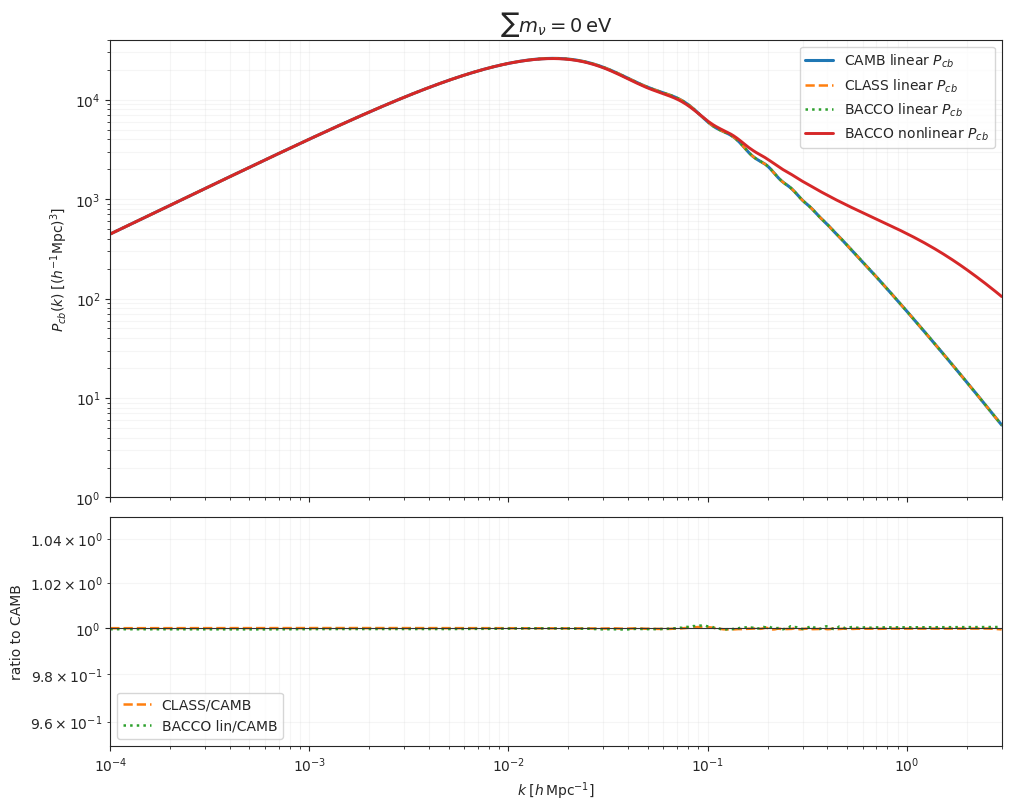

In [47]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=2.2, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, Pkbc_CLASS, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_ref, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl_ref, color="C3", lw=2.1, label=r"BACCO nonlinear $P_{cb}$")


ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = 0\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pkbc_CLASS / P_camb_cb_grid, color="C1", lw=1.8, ls="--", label="CLASS/CAMB")
axr.semilogx(k_h, pk_ref / P_camb_cb_grid, color="C2", lw=1.8, ls=":", label="BACCO lin/CAMB")
#axr.semilogx(k_h, pk_nl_ref / P_camb_cb_grid, color="C3", lw=1.5, label="BACCO nl/CAMB")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.95,1.05)
axr.legend(loc=3)
axr.grid(True, which="both", alpha=0.18)

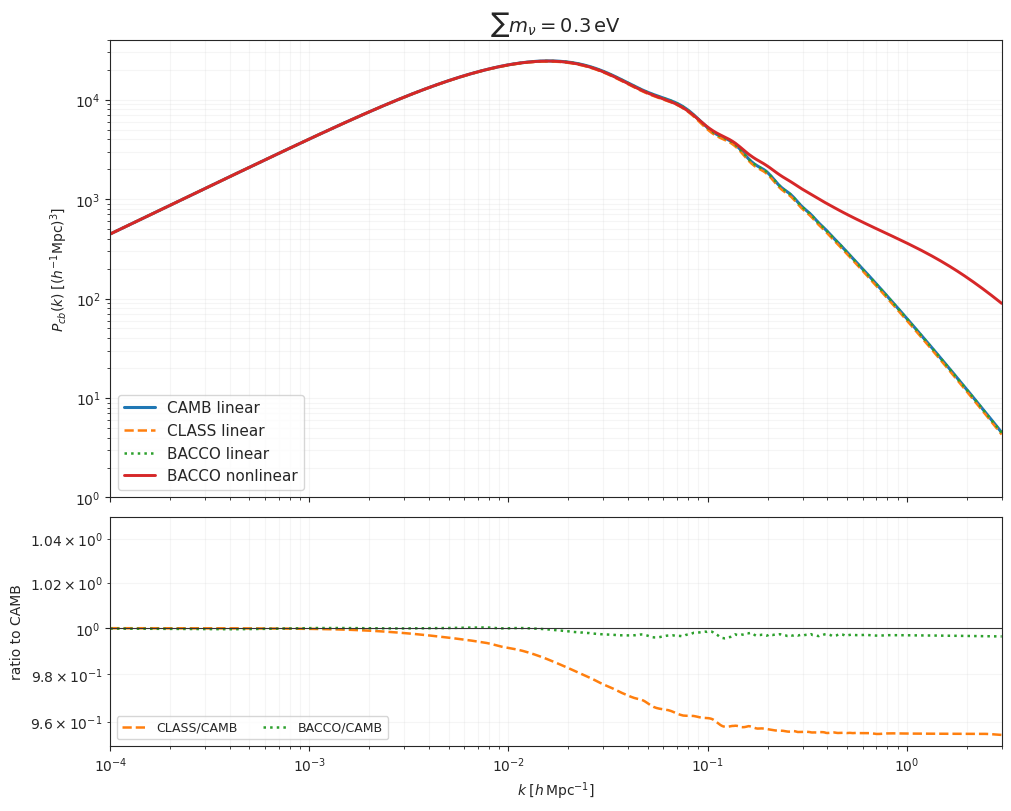

In [48]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.loglog(k_h, P_camb_cb_grid_nu, color="C0", lw=2.2, label=r"CAMB linear")
ax.loglog(k_h, Pkbc_CLASS_nu, color="C1", lw=1.8, ls="--", label=r"CLASS linear")
ax.loglog(k_h, pk_lin, color="C2", lw=1.8, ls=":", label=r"BACCO linear ")
ax.loglog(k_h, pk_nl, color="C3", lw=2.1, label=r"BACCO nonlinear")


ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend(loc=3,prop={'size': 11})
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = {mass}\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pkbc_CLASS_nu / P_camb_cb_grid_nu, color="C1", lw=1.8, ls="--", label="CLASS/CAMB")
axr.semilogx(k_h, pk_lin / P_camb_cb_grid_nu, color="C2", lw=1.8, ls=":", label="BACCO/CAMB")
#axr.semilogx(k_h, pk_nl / P_camb_cb_grid_nu, color="C3", lw=1.5, label="BACCO_NL/CAMB")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.95,1.05)
axr.legend(loc=3,prop={'size': 9},ncol=3)
axr.grid(True, which="both", alpha=0.18)
#plt.savefig('spectra_ref.pgf')

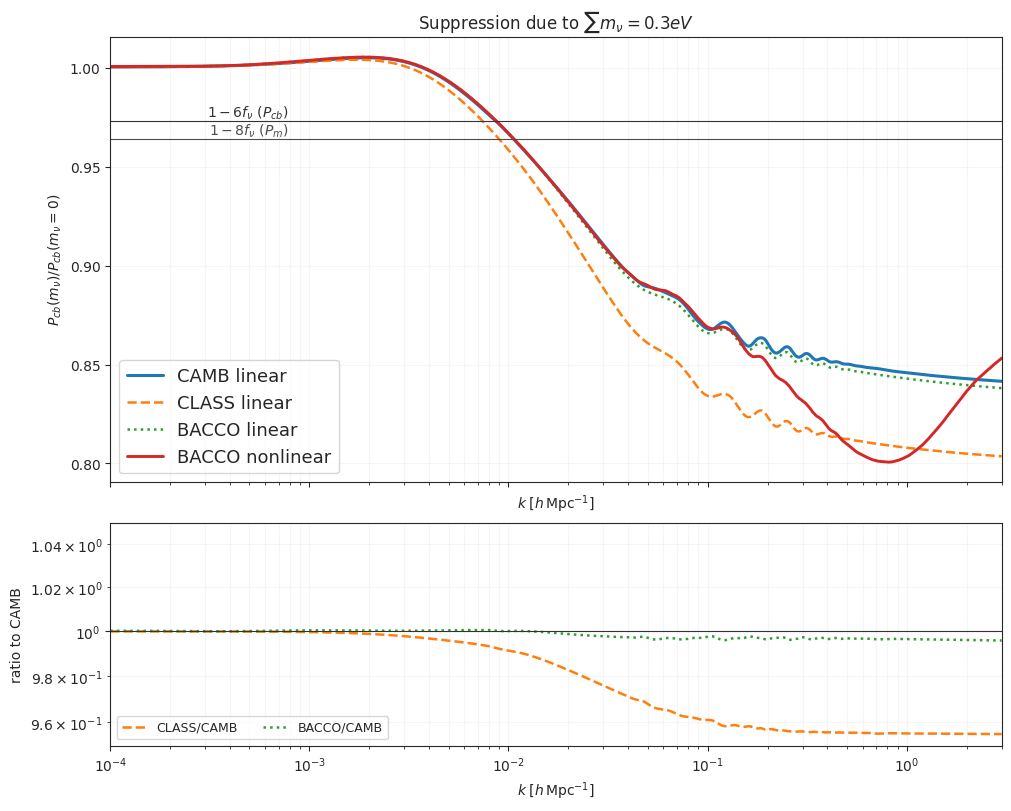

BACCO: 0.8380714376851651
CLASS: 0.8035802317403489
CAMB: 0.841529634548913
0.003458196863747931


In [49]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# Ratios massive / massless
ratio_camb     = P_camb_cb_grid_nu / P_camb_cb_grid
ratio_class    = Pkbc_CLASS_nu    / Pkbc_CLASS
ratio_bacco    = pk_lin           / pk_ref
ratio_bacco_nl = pk_nl            / pk_nl_ref

ax.semilogx(k_h,ratio_camb,color="C0",lw=2.2,label="CAMB linear",)
ax.semilogx(k_h,ratio_class,color="C1",lw=1.8,ls="--",label="CLASS linear",)
ax.semilogx(k_h,ratio_bacco,color="C2",lw=1.8,ls=":",label="BACCO linear",)
ax.semilogx(k_h,ratio_bacco_nl,color="C3",lw=2.1,label="BACCO nonlinear",)


ax.axhline(supp_Pcb, color="0.2", lw=0.8)
ax.axhline(supp_P,   color="0.3", lw=0.8)

ax.annotate(
    r"$1-6f_\nu$ ($P_{cb}$)",
    xy=(0.2, supp_Pcb),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.2",
)

ax.annotate(
    r"$1-8f_\nu$ ($P_m$)",
    xy=(0.2, supp_P),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.3",
)

ax.set_xscale("log")
ax.set_xlim(k_h.min(), k_h.max())

ax.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$P_{cb}(m_\nu) / P_{cb}(m_\nu=0)$"
)

ax.set_title(rf"Suppression due to $\sum m_\nu = {mass}eV $")

ax.legend(prop={'size': 13})
ax.grid(True, which="both", alpha=0.18)

axr.semilogx(k_h, ratio_class / ratio_camb, color="C1", lw=1.8, ls="--", label="CLASS/CAMB")
axr.semilogx(k_h, ratio_bacco / ratio_camb, color="C2", lw=1.8, ls=":", label="BACCO/CAMB")
#axr.semilogx(k_h, ratio_bacco_nl / ratio_camb, color="C3", lw=1.5, label="BACCO_NL/CAMB")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.95,1.05)
axr.legend(loc=3,prop={'size': 9},ncol=3)
axr.grid(True, which="both", alpha=0.18)


plt.show()
#plt.savefig('supp_ref_006.pgf')


print("BACCO:",ratio_bacco[-1])
print("CLASS:",ratio_class[-1])
print("CAMB:",ratio_camb[-1])
print(ratio_camb[-1]-ratio_bacco[-1])